In [2]:
"""Código-base do Laboratório L2 — Criptografia Assimétrica.

Complete somente os trechos marcados com TODO. Não inclua chaves privadas,
senhas ou dados reais no arquivo de entrega.
"""

from __future__ import annotations

import base64
import hashlib
import json
import os
from pathlib import Path
from typing import Any

from cryptography.exceptions import InvalidSignature
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding, rsa
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

AAD = b"L2-CCSC-2026"

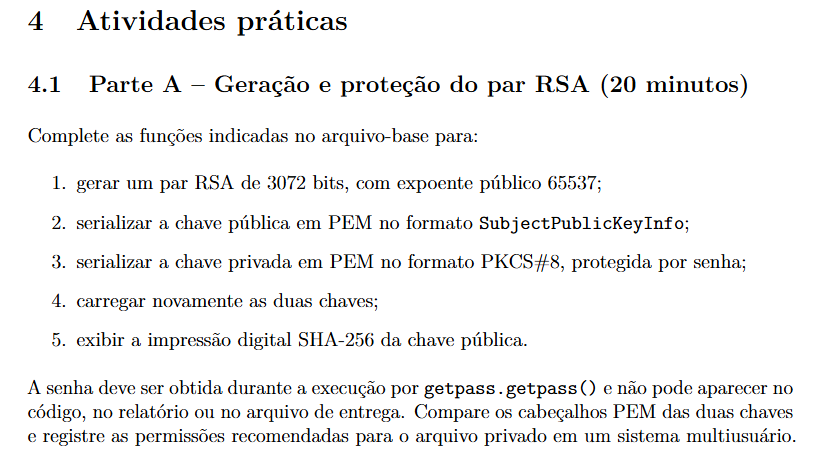

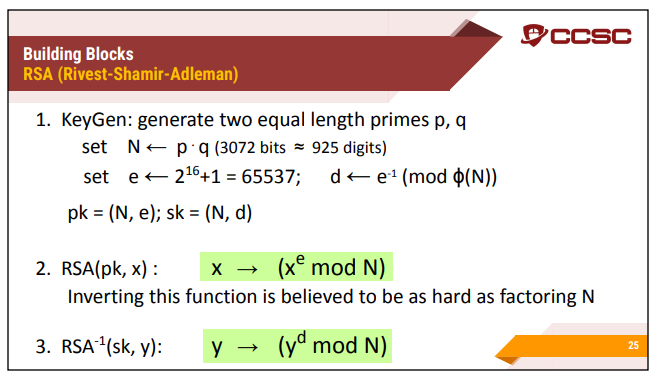

In [19]:
expoente_publico_e = 65537
tamanho_chave_bits = 3072
# Esse código do "rsa.generate_private_key" já faz a geração do par de chaves RSA. A ideia é pegar o e=65537 e tamanho =3072 bits. Gerar P e Q aleatórios de tamanho ~1536bits.
# Depois calcula o N=P*Q 3072 bits, calcula pela função de euler phi(N)=(P-1)*(Q-1)=Totient.
# Pega o expoente publico "e" calcula o expoente privado "d" = e^-1 mod Totient
# Chave_publica = (N,e)
# Chave_privada = (N,d)

# Ai vem aquela ideia de "a ida é rapida e facil, mas a volta é dificil levaria seculos":
# ida: N=P*Q trivial
# volta: dado N encontre P e Q (mesma ideia de fatorar)
chave_privada = rsa.generate_private_key(public_exponent=expoente_publico_e, key_size=tamanho_chave_bits)
print(chave_privada.private_numbers().d)
print(chave_privada.private_numbers().public_numbers.n)
print(chave_privada.private_numbers().public_numbers.e)



1565177045433875228987671815483587277531671841445460171926400075999231308768004854852775618860566738704636793254431885786430763791815976070776281097397340545039430002402559352813468177465273646223871053701535476604782886405368213902463167473212887903928817437020598785281454986818175083482862136231293228726300679700322680246615782848909668289934090369508149110788896133051115044118452554190206983817777917062459014555821671103356612946820293725855316448629685226610633414040043340699389870109511322757762273413975629598813110477127156603844273373423834071214835726744149597047002576654274182151639495039062954807562208196362368370243175729335762974818900612611318455991935005950195478026404021408583373905275334811501268988106759217352352155852268784859311401062993519111279238329676889237626703036791131519143779559039219035434717939234083181036037890081426505736949909122738842425460992983342024395233990499320921690922351
34673722861257079413242195065272148125675859000054463903033948579702071182

In [21]:
chave_privada = rsa.generate_private_key(public_exponent=expoente_publico_e, key_size=tamanho_chave_bits)
chave_publica = chave_privada.public_key()

print(chave_privada)
print(chave_publica)

In [25]:
print(chave_privada.key_size)
print(chave_publica.key_size)

3072
3072


In [ ]:
# Para a primeira tarefa, deve-se gerar o par de chaves RSA (publica e privada). Poderem neste processo preciso inicialmente gerar 2 números primos P e Q de tamanho iguais e aleatórios.abs

# Para gerar estes números de maneira aleatória vimos no lab anterior a lib "secrets".
# import secrets

# Porém preciso saber se são primos. Isso exige o teste de primalidade que em PAA vi ser o AKS(deterministico +lento) ou Miller-rabin (probabilistico + rapido). Vou do mais rapido
# ja ia fazendo errado... a lib cryptography ja tem essa função.





def gerar_par_rsa():
    """Retorna (chave_privada, chave_publica) para RSA-3072/e=65537."""
    # TODO: implemente.

    expoente_publico_e = 65537
    tamanho_chave_bits = 3072
    # Esse código do "rsa.generate_private_key" já faz a geração do par de chaves RSA. A ideia é pegar o e=65537 e tamanho =3072 bits. Gerar P e Q aleatórios de tamanho ~1536bits.
    # Depois calcula o N=P*Q 3072 bits, calcula pela função de euler phi(N)=(P-1)*(Q-1)=Totient.
    # Pega o expoente publico "e" calcula o expoente privado "d" = e^-1 mod Totient
    # Chave_publica = (N,e)
    # Chave_privada = (N,d)

    # Ai vem aquela ideia de "a ida é rapida e facil, mas a volta é dificil levaria seculos":
    # ida: N=P*Q trivial
    # volta: dado N encontre P e Q (mesma ideia de fatorar N)
    chave_privada = rsa.generate_private_key(public_exponent=expoente_publico_e, key_size=tamanho_chave_bits) # (N, e, d, p, q, ...)
    chave_publica = chave_privada.public_key()                                                                # (N, e) 

    return chave_privada, chave_publica

Segunda função:

In [ ]:
def salvar_chaves(chave_privada, chave_publica, senha: bytes,
                  pasta: Path = Path("chaves")) -> None:
    """Salva a chave privada em PKCS#8 cifrado e a pública em SPKI/PEM.""" # SPKI da professora significa exatamente Subject Public Key Info basicamente não guarda só a chave, mas o algoritmo usado para ela, no caso RSA
    # TODO: crie a pasta, serialize e grave as duas chaves.

    # Criar a pasta caso não exista
    pasta.mkdir(parents=True, exist_ok=True)


    # Me baseei numa leitura da documentação da lib cryptography, mapa mental no excalidraw

    # 3. serializar a chave privada em PEM no formato PKCS#8, protegida por senha;
    chave_priv_serializada_pem_pkcs8 = chave_privada.private_bytes( # chave privada uso ".private_bytes()"
        encoding = serialization.Encoding.PEM, # em PEM uso "serialization.Encoding.PEM"
        format = serialization.PrivateFormat.PKCS8, # em PKCS8 uso "serialization.PrivateFormat.PKCS8"
        encryption_algorithm = serialization.BestAvailableEncryption(senha) # e com senha uso "serialization.BestAvailableEncryption(senha no argumento da função "salvar chaves")"
    )
    # 2. serializar a chave pública em PEM no formato SubjectPublicKeyInfo;
    chave_publ_serializada_pem_subjectpubkeyinf = chave_publica.public_bytes( # chave publica uso "public_bytes"
        encoding= serialization.Encoding.PEM, # em PEM uso "serialization.Encoding.PEM"
        format = serialization.PublicFormat.SubjectPublicKeyInfo # no formato SubjectPublicKeyInfo uso "serialization.PublicFormat.SubjectPublicKeyInfo"
    )

    # Salvo os trem q fiz na pasta que vou passar no argumento da função
    with open(f"{pasta}/chave_privada_serializada_pem_pkcs8", "wb") as f:
        f.write(chave_priv_serializada_pem_pkcs8)
    with open(f"{pasta}/chave_publica_serializada_pem_SubjectPublicKeyInfo", "wb") as f:
        f.write(chave_publ_serializada_pem_subjectpubkeyinf)
    # raise NotImplementedError

Funções 3 e 4

In [ ]:
def carregar_chave_privada(caminho: Path, senha: bytes):
    """Carrega uma chave privada PEM protegida por senha."""
    # TODO: implemente.
    with open(caminho, "rb") as f:
        chave_privada_arquivo = f.read()
    chave_privada_regarregada = serialization.load_pem_private_key(chave_privada_arquivo, senha) # Preciso de senha para a privada :)
    return chave_privada_regarregada


def carregar_chave_publica(caminho: Path):
    """Carrega uma chave pública PEM."""
    # TODO: implemente.
    with open(caminho, "rb") as f:
        chave_public_arquivo = f.read()
    chave_public_regarregada = serialization.load_pem_public_key(chave_public_arquivo) # aqui na publica n preciso
    return chave_public_regarregada

In [ ]:

# def gerar_par_rsa():
#     """Retorna (chave_privada, chave_publica) para RSA-3072/e=65537."""
#     # TODO: implemente.
#     raise NotImplementedError


def salvar_chaves(chave_privada, chave_publica, senha: bytes,
                  pasta: Path = Path("chaves")) -> None:
    """Salva a chave privada em PKCS#8 cifrado e a pública em SPKI/PEM."""
    # TODO: crie a pasta, serialize e grave as duas chaves.
    raise NotImplementedError


def carregar_chave_privada(caminho: Path, senha: bytes):
    """Carrega uma chave privada PEM protegida por senha."""
    # TODO: implemente.
    raise NotImplementedError


def carregar_chave_publica(caminho: Path):
    """Carrega uma chave pública PEM."""
    # TODO: implemente.
    raise NotImplementedError


def fingerprint_publica(chave_publica) -> str:
    """Retorna SHA-256 do DER/SPKI da chave pública em hexadecimal."""
    # TODO: serialize em DER/SPKI e calcule SHA-256.
    raise NotImplementedError


def _b64e(dados: bytes) -> str:
    return base64.b64encode(dados).decode("ascii")


def _b64d(texto: str) -> bytes:
    return base64.b64decode(texto.encode("ascii"), validate=True)


def cifrar_arquivo_hibrido(entrada: Path, saida: Path,
                           chave_publica) -> None:
    """Cifra um arquivo com AES-256-GCM e encapsula a chave com RSA-OAEP."""
    # TODO:
    # 1) leia bytes; 2) gere chave AES e nonce; 3) cifre com AAD;
    # 4) encapsule a chave AES com RSA-OAEP/SHA-256;
    # 5) grave o contêiner JSON com campos Base64.
    raise NotImplementedError


def decifrar_arquivo_hibrido(entrada: Path, saida: Path,
                             chave_privada) -> None:
    """Valida o contêiner, recupera a chave AES e decifra o arquivo."""
    # TODO: faça o processo inverso e rejeite algoritmo/AAD inesperados.
    raise NotImplementedError


def assinar(dados: bytes, chave_privada) -> bytes:
    """Assina dados usando RSA-PSS/MGF1-SHA256/SHA256."""
    # TODO: implemente.
    raise NotImplementedError


def verificar_assinatura(dados: bytes, assinatura: bytes,
                          chave_publica) -> bool:
    """Retorna True para assinatura válida e False para InvalidSignature."""
    # TODO: capture especificamente InvalidSignature.
    raise NotImplementedError


def sha256_arquivo(caminho: Path) -> str:
    return hashlib.sha256(caminho.read_bytes()).hexdigest()


def alterar_primeiro_byte_cifrado(entrada: Path, saida: Path) -> None:
    """Cria cópia adulterada do contêiner para o teste negativo."""
    pacote: dict[str, Any] = json.loads(entrada.read_text(encoding="utf-8"))
    cifrado = bytearray(_b64d(pacote["cifrado"]))
    if not cifrado:
        raise ValueError("Campo cifrado vazio")
    cifrado[0] ^= 0x01
    pacote["cifrado"] = _b64e(bytes(cifrado))
    saida.write_text(json.dumps(pacote, indent=2), encoding="utf-8")
